# Plot one TR from subject 01, movie run 1

This notebook loads the 4D BOLD NIfTI image, selects one volume with Nilearn, and displays orthogonal EPI slices.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image, plotting

## Select the data and TR

`TR_INDEX` is zero-based, so index 225 refers to the 226th acquired volume.

In [2]:
bold_path = Path(
    "ds000113/sub-01/ses-movie/func/"
    "sub-01_ses-movie_task-movie_run-1_bold.nii.gz"
)
tr_index = 225
output_path = Path(f"sub-01_run-1_TR-{tr_index}.png")

In [3]:
bold_img = nib.load(bold_path)

if len(bold_img.shape) != 4:
    raise ValueError(f"Expected a 4D BOLD image, got shape {bold_img.shape}")
if not 0 <= tr_index < bold_img.shape[3]:
    raise IndexError(
        f"tr_index={tr_index} is outside the valid range "
        f"0..{bold_img.shape[3] - 1}"
    )

tr_seconds = bold_img.header.get_zooms()[3]
print(f"BOLD shape: {bold_img.shape}")
print(f"Voxel sizes and TR: {bold_img.header.get_zooms()}")
print(f"Selected TR: {tr_index} (t ≈ {tr_index * tr_seconds:.1f} s)")

BOLD shape: (80, 80, 35, 451)
Voxel sizes and TR: (3.0, 3.0, 3.3000004, 2.0000007)
Selected TR: 225 (t ≈ 450.0 s)


## Extract and plot one volume

/tmp/ipykernel_27391/1419442646.py:3: UserWarning: Casting data from int32 to float32
  display = plotting.plot_epi(


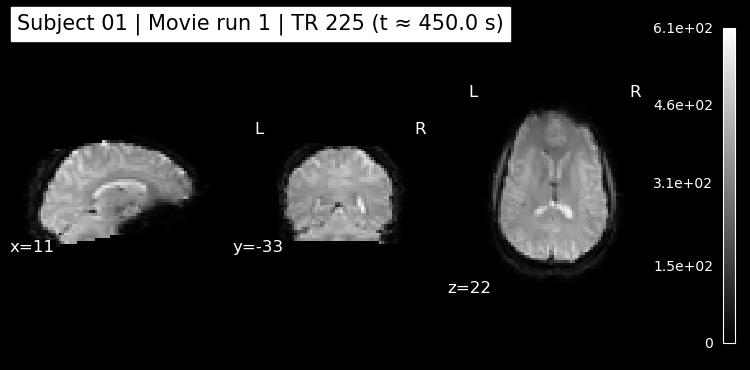

Saved plot to: /home/jovyan/junruz/forrestgump/sub-01_run-1_TR-225.png


In [4]:
one_tr = image.index_img(bold_img, tr_index)

display = plotting.plot_epi(
    one_tr,
    display_mode="ortho",
    black_bg=True,
    annotate=True,
    draw_cross=False,
    colorbar=True,
    title=(
        f"Subject 01 | Movie run 1 | TR {tr_index} "
        f"(t ≈ {tr_index * tr_seconds:.1f} s)"
    ),
)
display.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved plot to: {output_path.resolve()}")

## Register anatomical V1 to the movie data

The V1 definitions are subject-specific, thresholded FreeSurfer surface labels. The following cells rasterize both labels through the cortical ribbon in anatomical space, estimate an affine T1-to-mean-EPI registration using mutual information, and resample the V1 mask into the movie grid with nearest-neighbor interpolation.

In [5]:
import numpy as np
from scipy.ndimage import binary_dilation
from nibabel.freesurfer.io import read_geometry, read_label
from dipy.align.imaffine import (
    AffineRegistration,
    MutualInformationMetric,
    transform_centers_of_mass,
)
from dipy.align.transforms import (
    AffineTransform3D,
    RigidTransform3D,
    TranslationTransform3D,
)

In [6]:
freesurfer_dir = Path("studyforrest-aux/freesurfer/sub-01")
anatomical_path = freesurfer_dir / "mri/brain.mgz"
v1_mask_output = Path("sub-01_space-movie_V1-mask.nii.gz")
transform_output = Path("sub-01_anat-to-movie_affine.txt")
registration_qc_output = Path("sub-01_anat-to-movie_registration_QC.png")
v1_overlay_output = Path(f"sub-01_run-1_TR-{tr_index}_V1-overlay.png")

### Rasterize the anatomical V1 labels

For every labeled surface vertex, points are sampled between the white and pial surfaces. FreeSurfer's tkReg-RAS transform maps those points into the anatomical voxel grid.

In [7]:
anatomical_img = nib.load(anatomical_path)
anatomical_data = np.asarray(anatomical_img.dataobj, dtype=np.float32)
v1_anatomical = np.zeros(anatomical_img.shape, dtype=np.uint8)
tkr_ras_to_voxel = np.linalg.inv(anatomical_img.header.get_vox2ras_tkr())

for hemi in ("lh", "rh"):
    white, _ = read_geometry(freesurfer_dir / "surf" / f"{hemi}.white")
    pial, _ = read_geometry(freesurfer_dir / "surf" / f"{hemi}.pial")
    v1_vertices = read_label(
        freesurfer_dir / "label" / f"{hemi}.V1.thresh.label"
    )

    for depth in np.linspace(0.0, 1.0, 7):
        surface_points = (
            white[v1_vertices] * (1.0 - depth)
            + pial[v1_vertices] * depth
        )
        voxels = np.rint(
            nib.affines.apply_affine(tkr_ras_to_voxel, surface_points)
        ).astype(int)
        valid = np.all(
            (voxels >= 0) & (voxels < np.asarray(anatomical_img.shape)),
            axis=1,
        )
        voxels = voxels[valid]
        v1_anatomical[voxels[:, 0], voxels[:, 1], voxels[:, 2]] = 1

# Join neighboring samples into a continuous cortical mask.
v1_anatomical = binary_dilation(v1_anatomical, iterations=1)
print(f"Anatomical V1 voxels: {v1_anatomical.sum():,}")

Anatomical V1 voxels: 21,249


### Estimate the anatomical-to-EPI transform

The run mean supplies a higher-SNR EPI target. Registration proceeds from center-of-mass initialization through translation, rigid, and full affine optimization.

In [8]:
mean_epi = np.asarray(bold_img.dataobj, dtype=np.float32).mean(axis=3)

def robust_normalize(data):
    positive = data[data > 0]
    low, high = np.percentile(positive, [2, 98])
    return np.clip((data - low) / (high - low), 0, 1)


static_epi = robust_normalize(mean_epi)
moving_anatomy = robust_normalize(anatomical_data)
metric = MutualInformationMetric(nbins=32, sampling_proportion=0.3)
registration = AffineRegistration(
    metric=metric,
    level_iters=[100, 50, 20],
    sigmas=[3.0, 1.0, 0.0],
    factors=[4, 2, 1],
)

centered = transform_centers_of_mass(
    static_epi, bold_img.affine, moving_anatomy, anatomical_img.affine
)
translated = registration.optimize(
    static_epi,
    moving_anatomy,
    TranslationTransform3D(),
    params0=None,
    static_grid2world=bold_img.affine,
    moving_grid2world=anatomical_img.affine,
    starting_affine=centered.affine,
)
rigid = registration.optimize(
    static_epi,
    moving_anatomy,
    RigidTransform3D(),
    params0=None,
    static_grid2world=bold_img.affine,
    moving_grid2world=anatomical_img.affine,
    starting_affine=translated.affine,
)
anat_to_epi = registration.optimize(
    static_epi,
    moving_anatomy,
    AffineTransform3D(),
    params0=None,
    static_grid2world=bold_img.affine,
    moving_grid2world=anatomical_img.affine,
    starting_affine=rigid.affine,
)

registered_anatomy = anat_to_epi.transform(
    moving_anatomy, interpolation="linear"
)
v1_in_epi = anat_to_epi.transform(
    v1_anatomical.astype(np.float32), interpolation="nearest"
) > 0.5

v1_epi_img = nib.Nifti1Image(v1_in_epi.astype(np.uint8), bold_img.affine)
registered_anatomy_img = nib.Nifti1Image(
    registered_anatomy.astype(np.float32), bold_img.affine
)
mean_epi_img = nib.Nifti1Image(static_epi.astype(np.float32), bold_img.affine)
nib.save(v1_epi_img, v1_mask_output)
np.savetxt(transform_output, anat_to_epi.affine)

print(f"Movie-space V1 voxels: {v1_in_epi.sum():,}")
print(f"Saved mask: {v1_mask_output.resolve()}")
print(f"Saved affine: {transform_output.resolve()}")

Optimizing level 2 [max iter: 100]
Optimizing level 1 [max iter: 50]
Optimizing level 0 [max iter: 20]
Optimizing level 2 [max iter: 100]
Optimizing level 1 [max iter: 50]
Optimizing level 0 [max iter: 20]
Optimizing level 2 [max iter: 100]
Optimizing level 1 [max iter: 50]
Optimizing level 0 [max iter: 20]
Movie-space V1 voxels: 1,198
Saved mask: /home/jovyan/junruz/forrestgump/sub-01_space-movie_V1-mask.nii.gz
Saved affine: /home/jovyan/junruz/forrestgump/sub-01_anat-to-movie_affine.txt


### Registration quality control

The cyan contour is the transformed anatomical brain boundary; yellow is transformed V1. Their alignment with the mean EPI should be inspected before interpreting the V1 overlay.

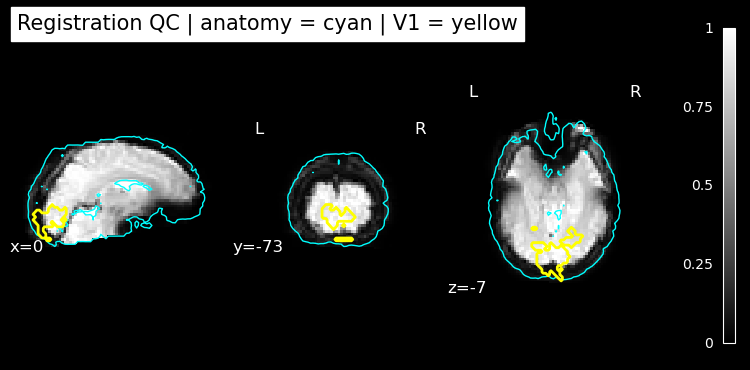

Saved QC: /home/jovyan/junruz/forrestgump/sub-01_anat-to-movie_registration_QC.png


In [15]:
v1_voxels = np.argwhere(v1_in_epi)
v1_world = nib.affines.apply_affine(bold_img.affine, v1_voxels)
v1_center = np.median(v1_world, axis=0)

coords = [14, -10, 1]

qc_display = plotting.plot_epi(
    mean_epi_img,
    display_mode="ortho",
    cut_coords=v1_center,
    black_bg=True,
    draw_cross=False,
    title="Registration QC | anatomy = cyan | V1 = yellow",
)
qc_display.add_contours(
    registered_anatomy_img, levels=[0.15], colors="cyan", linewidths=1.0
)
qc_display.add_contours(
    v1_epi_img, levels=[0.5], colors="yellow", linewidths=2.0
)
qc_display.savefig(registration_qc_output, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved QC: {registration_qc_output.resolve()}")

## One movie TR with anatomical V1 labeled

The yellow contour labels bilateral V1. Cuts are centered on the transformed V1 mask so the region is visible in all three orientations.

/tmp/ipykernel_27391/59855152.py:1: UserWarning: Casting data from int32 to float32
  v1_display = plotting.plot_epi(


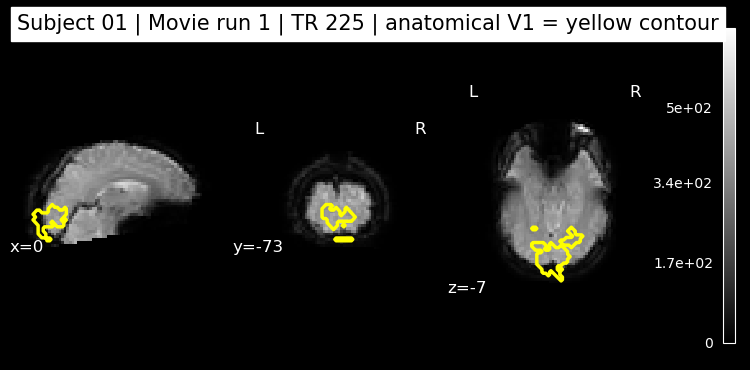

Saved V1 overlay: /home/jovyan/junruz/forrestgump/sub-01_run-1_TR-225_V1-overlay.png


In [10]:
v1_display = plotting.plot_epi(
    one_tr,
    display_mode="ortho",
    cut_coords=v1_center,
    black_bg=True,
    annotate=True,
    draw_cross=False,
    colorbar=True,
    title=(
        f"Subject 01 | Movie run 1 | TR {tr_index} | "
        "anatomical V1 = yellow contour"
    ),
)
v1_display.add_contours(
    v1_epi_img, levels=[0.5], colors="yellow", linewidths=2.5
)
v1_display.savefig(v1_overlay_output, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved V1 overlay: {v1_overlay_output.resolve()}")

## Interactive x/y/z coordinate explorer with V1 overlay

Move the sliders to inspect different world coordinates (millimeters). The sagittal, coronal, and axial views update together, and the anatomical V1 boundary remains visible in yellow. `continuous_update=False` redraws only after a slider is released.

In [11]:
import ipywidgets as widgets
from IPython.display import display as ipython_display

# Find the world-coordinate bounds of the EPI grid.
shape_3d = np.asarray(bold_img.shape[:3])
corner_voxels = np.asarray(
    [
        [i, j, k]
        for i in (0, shape_3d[0] - 1)
        for j in (0, shape_3d[1] - 1)
        for k in (0, shape_3d[2] - 1)
    ]
)
corner_world = nib.affines.apply_affine(bold_img.affine, corner_voxels)
world_min = np.floor(corner_world.min(axis=0))
world_max = np.ceil(corner_world.max(axis=0))

def coordinate_slider(axis, axis_index):
    return widgets.FloatSlider(
        value=float(np.round(v1_center[axis_index])),
        min=float(world_min[axis_index]),
        max=float(world_max[axis_index]),
        step=1.0,
        description=f"{axis} (mm)",
        continuous_update=False,
        readout_format=".0f",
        layout=widgets.Layout(width="95%"),
        style={"description_width": "70px"},
    )


x_slider = coordinate_slider("x", 0)
y_slider = coordinate_slider("y", 1)
z_slider = coordinate_slider("z", 2)
interactive_output = widgets.Output()

def redraw_v1_view(*_):
    with interactive_output:
        interactive_output.clear_output(wait=True)
        coordinates = (x_slider.value, y_slider.value, z_slider.value)
        viewer = plotting.plot_epi(
            one_tr,
            display_mode="ortho",
            cut_coords=coordinates,
            black_bg=True,
            annotate=True,
            draw_cross=True,
            colorbar=True,
            title=(
                f"TR {tr_index} | x={coordinates[0]:.0f}, "
                f"y={coordinates[1]:.0f}, z={coordinates[2]:.0f} mm | "
                "V1 = yellow"
            ),
        )
        viewer.add_contours(
            v1_epi_img,
            levels=[0.5],
            colors="yellow",
            linewidths=2.5,
        )
        plt.show()
        viewer.close()


for slider in (x_slider, y_slider, z_slider):
    slider.observe(redraw_v1_view, names="value")

controls = widgets.VBox([x_slider, y_slider, z_slider])
ipython_display(controls, interactive_output)
redraw_v1_view()

Output()